
# Sentiment Analysis on Amazon Reviews

## Business Objective

To analyze Amazon customer reviews and build a machine learning model 
that classifies reviews into sentiment categories (Positive / Negative).

The project includes EDA, text preprocessing, feature extraction using TF-IDF, 
model training, evaluation, and saving the best model for deployment.


In [7]:
!pip install langdetect 
!pip install seaborn
!pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
#usecase: analysing amazon reviews
#Import necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from langdetect import detect
import string

In [9]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [10]:
df = pd.read_excel("dataset.xlsx")
df.head()


,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."



##  Dataset Overview

Check data types and non-null values to understand data quality.


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   1440 non-null   object
 1   rating  1440 non-null   int64 
 2   body    1440 non-null   object
dtypes: int64(1), object(2)
memory usage: 33.9+ KB


In [12]:
df.shape

(1440, 3)

In [13]:
df.columns

Index(['title', 'rating', 'body'], dtype='object')


## Step 3: Missing Value Check

Identify whether any missing values exist in the dataset.


In [14]:
df.isnull().sum()

title     0
rating    0
body      0
dtype: int64

In [15]:
df.describe()

,rating
count,1440.000000
mean,3.173611
std,1.584453
min,1.000000
25%,1.000000
50%,4.000000
75%,5.000000
max,5.000000


In [16]:
df.dtypes

title     object
rating     int64
body      object
dtype: object

In [17]:
#Language dedect
data = df[df['body'].apply(lambda x: detect(x) != 'hi')]
data

,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."
...,...,...,...
1435,Excellent mobile,5,Excellent mobile
1436,Never expected from samsung,1,"All over mobile performance is very poor, neve..."
1437,Good value for money,5,Battery life is good but camera clarity could ...
1438,Unreal and whitish display,1,"It's a very bad product, highly dissatisfied....."


In [18]:
# Make sure to use the filtered data for the rest of the notebook
df = data
df.reset_index(drop=True, inplace=True) 
print(f"Shape of the dataframe after filtering: {df.shape}")

Shape of the dataframe after filtering: (1429, 3)



## Step 4: Rating / Sentiment Distribution

Analyze class distribution to understand balance between categories.


In [19]:
#Distinct values of rating and its count
print(f"rating value count: \n{data['rating'].value_counts()}")

rating value count: 
rating
5    418
1    378
4    309
3    199
2    125
Name: count, dtype: int64


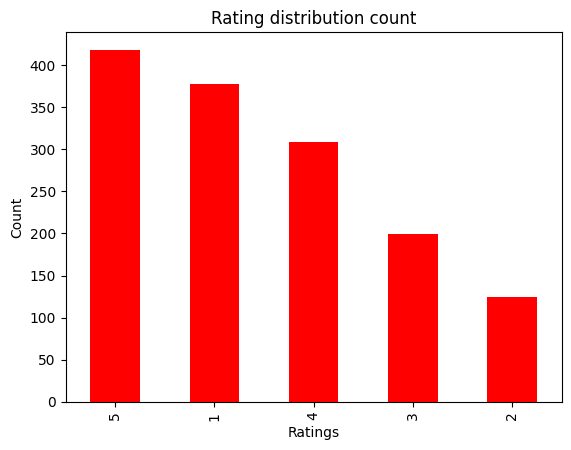

In [20]:
#Bar plot to visualize the total counts of each rating
data['rating'].value_counts().plot.bar(color = 'red')
plt.title('Rating distribution count')
plt.xlabel('Ratings')
plt.ylabel('Count')
plt.show()

In [21]:
# Sentiment Mapping
def get_sentiment(rating):
    if rating <= 2:
        return 'Negative'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Positive'

In [22]:
df['sentiment'] = df['rating'].apply(get_sentiment)
df['sentiment']

0       Negative
1        Neutral
2       Positive
3       Negative
4       Negative
          ...   
1424    Positive
1425    Negative
1426    Positive
1427    Negative
1428    Positive
Name: sentiment, Length: 1429, dtype: object

In [23]:
# Text cleaning function
def clean_text(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    stop_words = set(stopwords.words('english'))
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

In [24]:
df['clean_body'] = df['body'].astype(str).apply(clean_text)

In [25]:
text_data = {
    sentiment: " ".join(df[df['sentiment'] == sentiment]['clean_body'])
    for sentiment in ['Positive', 'Neutral', 'Negative']
}



## WordCloud Visualization

Visualize the most frequently occurring words in the reviews.


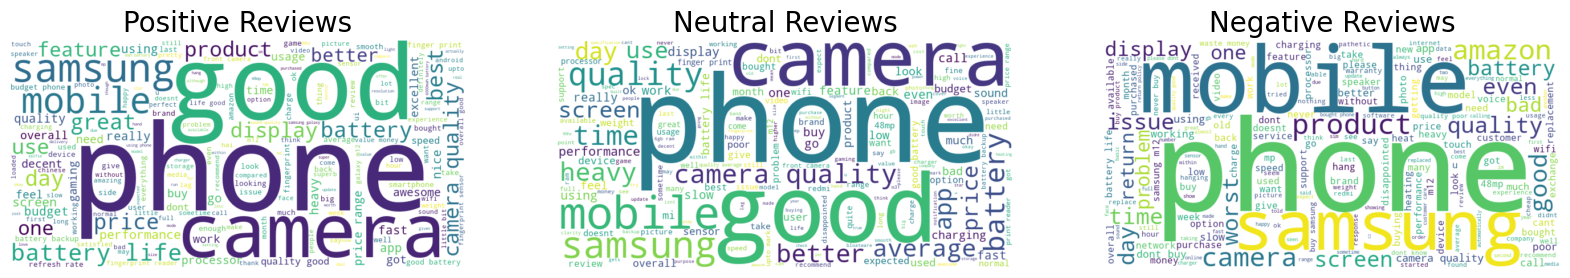

In [26]:
plt.figure(figsize=(20, 8))
for i, (sentiment, text) in enumerate(text_data.items(), 1):
    plt.subplot(1, 3, i)
    wc = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(text)
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f'{sentiment} Reviews', fontsize=20)
    plt.axis('off')



## EDA Conclusion

- Dataset structure and quality were verified.
- Class distribution was analyzed.
- Frequently used words were visualized.

The data is suitable for NLP preprocessing and model building.


In [27]:
df

,title,rating,body,sentiment,clean_body
0,Horrible product,1,Very disappointed with the overall performance...,Negative,disappointed overall performance samsung
1,Camera quality is not like 48 megapixel,3,Camera quality is low,Neutral,camera quality low
2,Overall,4,"Got the mobile on the launch date,Battery must...",Positive,got mobile launch datebattery must appreciated...
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....,Negative,1 doesnt work 50ghz wifi frequency 24ghz old s...
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp...",Negative,worth buyingfaulty software poor display quali...
...,...,...,...,...,...
1424,Excellent mobile,5,Excellent mobile,Positive,excellent mobile
1425,Never expected from samsung,1,"All over mobile performance is very poor, neve...",Negative,mobile performance poor never buy one product ...
1426,Good value for money,5,Battery life is good but camera clarity could ...,Positive,battery life good camera clarity could little ...
1427,Unreal and whitish display,1,"It's a very bad product, highly dissatisfied.....",Negative,bad product highly dissatisfied specifically c...


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [29]:
df_filtered=df[["sentiment","clean_body"]]

In [30]:
df_filtered

,sentiment,clean_body
0,Negative,disappointed overall performance samsung
1,Neutral,camera quality low
2,Positive,got mobile launch datebattery must appreciated...
3,Negative,1 doesnt work 50ghz wifi frequency 24ghz old s...
4,Negative,worth buyingfaulty software poor display quali...
...,...,...
1424,Positive,excellent mobile
1425,Negative,mobile performance poor never buy one product ...
1426,Positive,battery life good camera clarity could little ...
1427,Negative,bad product highly dissatisfied specifically c...



## Step 6: Feature Extraction (TF-IDF)

Convert cleaned text into numerical vectors based on word importance.


In [31]:
tf=TfidfVectorizer()
x=tf.fit_transform(df_filtered['clean_body'])
y=df_filtered['sentiment']

In [32]:
x.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(1429, 7395))


## Step 7: Train-Test Split

Split the dataset into training and testing sets for evaluation.


In [33]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

Training Machine Learning Models


## Step 8: Logistic Regression Model

Train Logistic Regression as a baseline classifier.


In [34]:
LRmodel=LogisticRegression(max_iter=1000)

In [35]:
LRmodel.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [36]:
y_predLR=LRmodel.predict(X_test)

In [37]:
#Evaluation
print("Classification Report:\n")
print(classification_report(y_test,y_predLR))

Classification Report:

              precision    recall  f1-score   support

    Negative       0.75      0.81      0.78       101
     Neutral       0.67      0.05      0.09        40
    Positive       0.75      0.90      0.82       145

    accuracy                           0.75       286
   macro avg       0.72      0.59      0.56       286
weighted avg       0.74      0.75      0.70       286



#MultinomialNB


## Step 9: Multinomial Naive Bayes Model

Train Naive Bayes classifier suitable for text data.


In [38]:
from sklearn.naive_bayes import MultinomialNB
model=MultinomialNB()
model.fit(X_train,y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [39]:
y_predmnb=model.predict(X_test)

In [40]:
#Evaluation
print("Classification Report:\n")
print(classification_report(y_test,y_predmnb))

Classification Report:

              precision    recall  f1-score   support

    Negative       0.85      0.59      0.70       101
     Neutral       0.00      0.00      0.00        40
    Positive       0.66      0.97      0.78       145

    accuracy                           0.70       286
   macro avg       0.50      0.52      0.49       286
weighted avg       0.63      0.70      0.64       286



C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

# SVM Model


## Step 10: Support Vector Machine (SVM)

Train Linear SVM model for high-dimensional TF-IDF features.


In [41]:
from sklearn.svm import LinearSVC
model = LinearSVC()
model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [42]:
y_predsvm=model.predict(X_test)

In [43]:
#Evaluation
print("Classification Report:\n")
print(classification_report(y_test,y_predsvm))

Classification Report:

              precision    recall  f1-score   support

    Negative       0.72      0.80      0.76       101
     Neutral       0.36      0.12      0.19        40
    Positive       0.78      0.86      0.81       145

    accuracy                           0.73       286
   macro avg       0.62      0.59      0.59       286
weighted avg       0.70      0.73      0.71       286



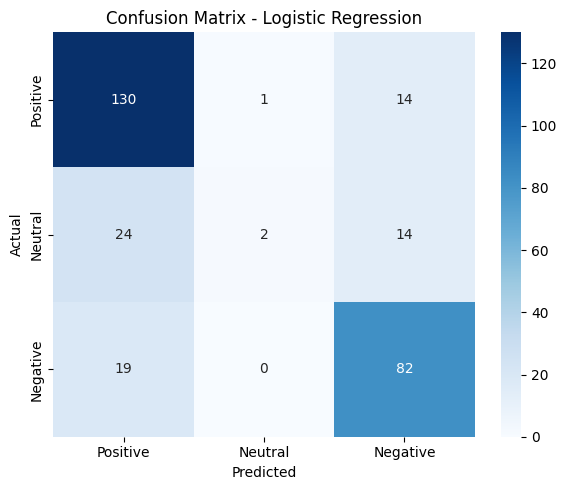

In [44]:
#Confusion Matrix
labels = ["Positive", "Neutral", "Negative"]
conf_matrix = confusion_matrix(y_test, y_predLR, labels=labels)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

Logistic Regression: 0.7483
Naive Bayes: 0.7028
SVM: 0.7343
Random Forest: 0.7413


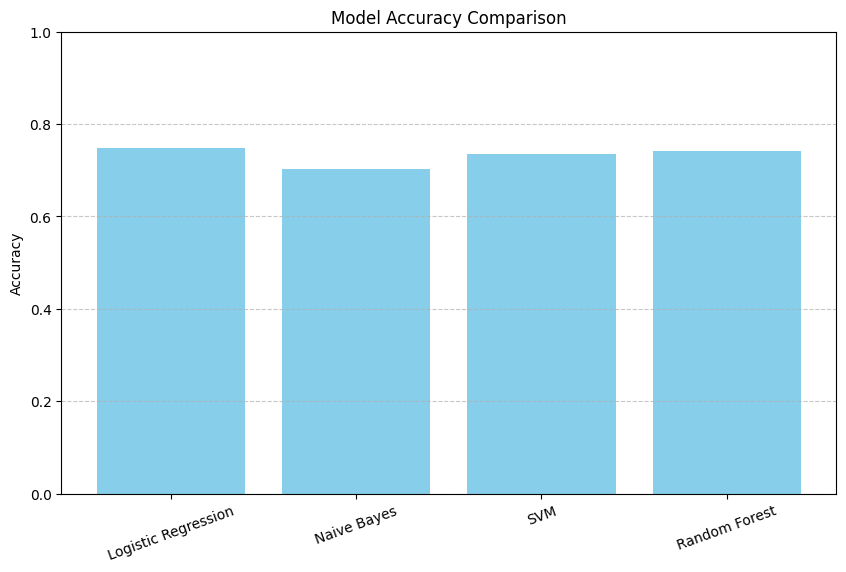

In [45]:
### Step 9: Model Evaluation and Accuracy Comparison
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "SVM": LinearSVC(),
    "Random Forest": RandomForestClassifier()
}
accuracies = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies[name] = acc
    print(f"{name}: {acc:.4f}")
# Plotting
plt.figure(figsize=(10,6))
plt.bar(accuracies.keys(), accuracies.values(), color='skyblue')
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [46]:
## Hyperparameter Tuning (Logistic Regression)
#Using GridSearchCV to find the best values of C and solver through 5-fold cross-validation.
from sklearn.model_selection import GridSearchCV
params = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['liblinear', 'lbfgs']
}

grid = GridSearchCV(LogisticRegression(max_iter=1000), params, cv=5)
grid.fit(X_train,y_train)
print("Best params:",grid.best_params_)
print("Best score:",grid.best_score_)

C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be

Best params: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best score: 0.7725427104880105


C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
20 fits failed out of a total of 40.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\Admin\AppData\Roaming\Python\Python313\site-p


##  Saving the Best Model

Save the trained model for deployment and future predictions.


In [47]:
#Saving the Final Tuned Model for Deployment
# Logistic Regression model along with the TF-IDF vectorizer is saved using pickle to enable future predictions and deployment.
import pickle

with open("model_and_vectorizer.pkl", "wb") as f:
    pickle.dump({"model": LRmodel, "vectorizer": tf}, f)



##  Conclusion

Multiple machine learning models including Logistic Regression, Naive Bayes, SVM, and Random Forest were trained and evaluated using accuracy as the performance metric.

After comparing model performance and performing hyperparameter tuning using GridSearchCV, Logistic Regression achieved the best overall performance.

Therefore, the tuned Logistic Regression model was selected as the final model and saved along with the TF-IDF vectorizer for deployment and real-time sentiment prediction.


In [48]:
import os
print(os.getcwd())


c:\Users\Admin\Desktop\DS Projects\Sentiment_Deployment
